# Módulo 2: Clasificación, Clustering y Ciclo de Vida
### Workshop: IA aplicada a Distribución de Energía
**Presentado por: Dr. Francisco Arduh - Xcapit**

---

## Repaso del Módulo 1

- Aprendimos **Regresión** (predecir un número: demanda en MW).
- Vimos que **Feature Engineering** (crear columnas con conocimiento del negocio) importa más que el algoritmo.
- Probamos un **Baseline**, **Regresión Lineal** y **Árbol de Decisión**.
- Vimos conceptos clave: **Features vs Target**, **Train/Test Split**, **Overfitting vs Underfitting**.

## ¿Qué viene hoy?

En el Módulo 1 predijimos un **número continuo** (demanda en MW). Hoy vamos a ver un tipo de problema distinto: **Clasificación**, donde el modelo predice una **categoría** (Normal/Anómalo, Sí/No). También vamos a explorar técnicas que funcionan **sin etiquetas** (aprendizaje no supervisado).

## Agenda de Hoy (~2 horas)

| Bloque | Tema | Duración |
|--------|------|----------|
| 1 | Clasificación completa (métricas, modelos, desbalanceo) | ~50 min |
| 2 | Aprendizaje No Supervisado (Clustering + PCA) | ~40 min |
| 3 | Ciclo de vida de un proyecto de ML (CRISP-DM) | ~30 min |

In [28]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (mean_absolute_error, accuracy_score, confusion_matrix,
                             classification_report, precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")
print("Librerías cargadas.")

Librerías cargadas.


### Regenerar datos del Módulo 1

Usamos el mismo dataset de demanda energética.

In [29]:
# Regenerar datos (misma semilla que Módulo 1)
np.random.seed(42)
fechas = pd.date_range("2024-01-01", "2024-12-31 23:00:00", freq="h")
n = len(fechas)
dia_del_anio = fechas.dayofyear
hora = fechas.hour
temperatura = 20 - 12*np.cos(2*np.pi*dia_del_anio/365+np.pi) + 4*np.sin(2*np.pi*hora/24) + np.random.normal(0, 2, n)
demanda = 300 + 0.8*(temperatura - 20)**2 + 8*np.sin(2*np.pi*(hora - 6)/24) + np.random.normal(0, 5, n)

df = pd.DataFrame({
    'fecha': fechas, 'temperatura': np.round(temperatura, 1),
    'hora': hora, 'dia_semana': fechas.dayofweek,
    'es_finde': (fechas.dayofweek >= 5).astype(int),
    'demanda_MW': np.round(demanda, 1)
})
print(f"Datos cargados: {len(df)} registros.")


Datos cargados: 8784 registros.


---
## Bloque 1: Clasificación Completa

### De Regresión a Clasificación

En el Módulo 1 predijimos un **número continuo** (demanda en MW). Eso es **Regresión**.

Pero muchos problemas del negocio no piden un número, sino una **decisión**:
- ¿Este patrón de consumo es **Normal** o **Anómalo**?
- ¿Esta lectura de medidor indica **fraude** o es **legítima**?
- ¿Este transformador va a **fallar** en los próximos 30 días?

En todos estos casos la respuesta es una **categoría** (Sí/No, Normal/Anómalo). Esto se llama **Clasificación**.

| | Regresión (Módulo 1) | Clasificación (hoy) |
|--|-----------|---------------|
| **¿Qué predice?** | Un número continuo | Una categoría |
| **Ejemplo** | "La demanda será 420 MW" | "Este consumo es anómalo" |
| **Métrica principal** | MAE (error en MW) | Precision, Recall, F1 |
| **Algoritmo** | `DecisionTreeRegressor` | `DecisionTreeClassifier` |

La mecánica es muy similar: tenemos features (X), un target (y), dividimos en train/test y entrenamos un modelo. Lo que cambia es **qué tipo de respuesta da el modelo** y **cómo medimos si lo hace bien**.

### 1.1 Framing del problema

**Caso de uso:** Detectar patrones de consumo anómalos que podrían indicar fraude, fallas en medidores, o conexiones ilegales.

El modelo de ML aprende a hacer esa clasificación **automáticamente** a partir de los datos, sin que nosotros definamos reglas manuales (como umbrales fijos). Esto es especialmente útil cuando los patrones son complejos y dependen de múltiples variables a la vez.

### 1.2 Preparar datos de clasificación

Necesitamos crear una **etiqueta** (target) que diga si cada registro es normal o anómalo.

En el mundo real, estas etiquetas vendrían de inspecciones de campo, reportes de técnicos, o alertas históricas del sistema SCADA. Acá las vamos a simular de forma realista, basándonos en patrones que un experto del dominio esperaría:

- **Temperaturas extremas** → equipos bajo estrés → más chance de falla
- **Horario de madrugada (1-5 AM)** → menos supervisión → más chance de fraude
- **Fines de semana** → menos personal de guardia → detección más lenta

In [30]:
# Simular anomalías realistas basadas en patrones del dominio
np.random.seed(42)

# Score de riesgo: combina factores que un experto esperaría
score_riesgo = np.zeros(len(df))
score_riesgo += 3.0 * ((df['hora'] >= 1) & (df['hora'] <= 5)).astype(float)  # Madrugada (fraude)
score_riesgo += 2.0 * (df['temperatura'] < 8).astype(float)                  # Frío extremo (estrés en equipos)
score_riesgo += 2.0 * (df['temperatura'] > 32).astype(float)                 # Calor extremo (estrés en equipos)
score_riesgo += 0.8 * df['es_finde']                                          # Fin de semana (menos supervisión)
score_riesgo += np.random.normal(0, 0.8, len(df))                             # Variabilidad (no todo es predecible)

# Si el score supera un umbral → anomalía (~20%)
umbral_anomalia = np.percentile(score_riesgo, 80)
df['anomalia'] = (score_riesgo > umbral_anomalia).astype(int)

print("Distribución de clases:")
print(df['anomalia'].value_counts())
print(f"\nPorcentaje de anomalías: {df['anomalia'].mean():.1%}")
print(f"\nConclusión: Solo ~20% de los registros son anomalías. El dataset está desbalanceado,")
print("y en problemas reales de energía este desbalance es mucho peor (fraude <5%, fallas <1%).")

Distribución de clases:
anomalia
0    7027
1    1757
Name: count, dtype: int64

Porcentaje de anomalías: 20.0%

Conclusión: Solo ~20% de los registros son anomalías. El dataset está desbalanceado,
y en problemas reales de energía este desbalance es mucho peor (fraude <5%, fallas <1%).


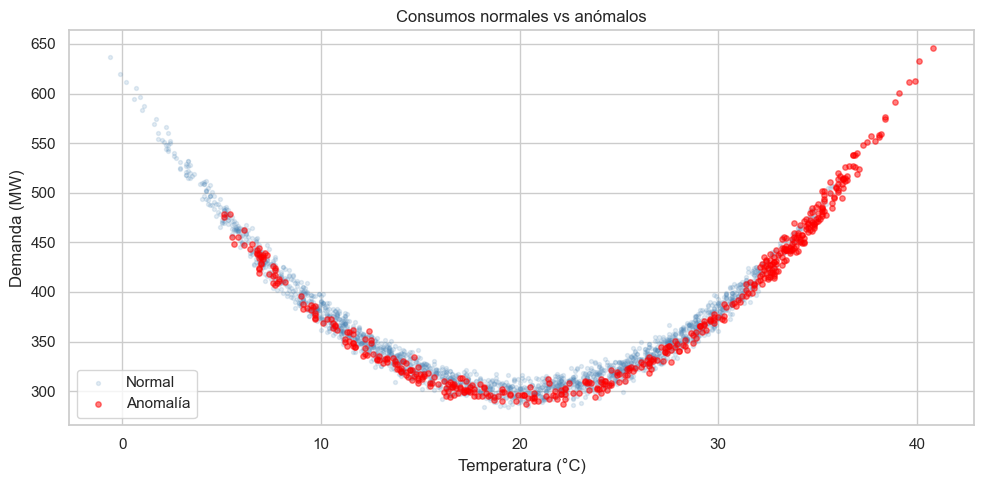

Las anomalías (rojo) son los puntos que se alejan del patrón esperado.
El modelo de clasificación debe aprender a distinguir rojos de azules.


In [31]:
# Visualizar: ¿dónde están las anomalías?
plt.figure(figsize=(10, 5))
muestra_normal = df[df['anomalia'] == 0].sample(2000, random_state=42)
muestra_anomala = df[df['anomalia'] == 1].sample(min(500, df['anomalia'].sum()), random_state=42)

plt.scatter(muestra_normal['temperatura'], muestra_normal['demanda_MW'],
            alpha=0.15, s=8, color='steelblue', label='Normal')
plt.scatter(muestra_anomala['temperatura'], muestra_anomala['demanda_MW'],
            alpha=0.5, s=15, color='red', label='Anomalía')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Demanda (MW)')
plt.title('Consumos normales vs anómalos')
plt.legend()
plt.tight_layout()
plt.show()

print("Las anomalías (rojo) son los puntos que se alejan del patrón esperado.")
print("El modelo de clasificación debe aprender a distinguir rojos de azules.")

Las anomalías son ~20% del total. En problemas reales de energía el desbalance puede ser mucho peor (fraude ~2-5%, fallas de transformador ~1%). Vamos a ver más adelante por qué esto es un problema para los modelos.

### Feature Engineering para Clasificación

Igual que en el Módulo 1 (donde `temp_cuadrada` mejoró mucho la regresión), acá creamos features con conocimiento del negocio:

- **`hora_madrugada`**: ¿es entre 1 y 5 AM? (horario típico de fraude)
- **`temp_extrema`**: ¿cuánto se aleja la temperatura de los 20°C? (estrés en equipos)

Estas features le "cuentan" al modelo lo que un experto ya sabe.

In [32]:
# Feature Engineering: crear columnas con conocimiento del negocio
df['hora_madrugada'] = ((df['hora'] >= 1) & (df['hora'] <= 5)).astype(int)
df['temp_extrema'] = np.abs(df['temperatura'] - 20)

# Split cronológico (mismo que Módulo 1)
corte = int(len(df) * 0.8)
features = ['temperatura', 'hora', 'es_finde', 'dia_semana', 'hora_madrugada', 'temp_extrema']

X_train = df.iloc[:corte][features]
X_test = df.iloc[corte:][features]
y_train = df.iloc[:corte]['anomalia']
y_test = df.iloc[corte:]['anomalia']

print(f"Entrenamiento: {len(X_train)} registros")
print(f"Test: {len(X_test)} registros")
print(f"Anomalías en test: {y_test.sum()} ({y_test.mean():.1%})")
print(f"\nFeatures: {features}")

Entrenamiento: 7027 registros
Test: 1757 registros
Anomalías en test: 427 (24.3%)

Features: ['temperatura', 'hora', 'es_finde', 'dia_semana', 'hora_madrugada', 'temp_extrema']


### 1.3 Primer modelo: Regresión Logística

A pesar del nombre, la **Regresión Logística es para clasificación**, no para regresión.

**¿Cómo funciona?** Combina las features para calcular una **probabilidad** entre 0 y 1. Si la probabilidad supera 0.5, clasifica como anomalía. Si no, como normal.

Es un modelo simple y rápido. Buen punto de partida para clasificación.

In [33]:
# Entrenar Regresión Logística
modelo_log = LogisticRegression(random_state=42, max_iter=1000)
modelo_log.fit(X_train, y_train)
pred_log = modelo_log.predict(X_test)

acc = accuracy_score(y_test, pred_log)
print(f"Accuracy: {acc:.1%}")
print(f"\nParece un buen número, pero ¡cuidado! Si el modelo dijera SIEMPRE 'Normal',")
print(f"tendría {1 - y_test.mean():.1%} de accuracy. Veamos la matriz de confusión para entender mejor.")

Accuracy: 88.2%

Parece un buen número, pero ¡cuidado! Si el modelo dijera SIEMPRE 'Normal',
tendría 75.7% de accuracy. Veamos la matriz de confusión para entender mejor.


### 1.4 Métricas de Clasificación (¡sección clave!)

**Accuracy sola NO alcanza.** Pensemos un ejemplo extremo:

Si el 97% de los datos son "Normal", un modelo que **SIEMPRE** diga "Normal" tiene 97% de accuracy. Pero no detecta **ninguna** anomalía. Sería completamente inútil.

Para entender realmente cómo se comporta un modelo, necesitamos la **Matriz de Confusión**: una tabla de 2x2 que cruza lo que el modelo predijo contra lo que realmente pasó.

```
                          Predicción del Modelo
                       ┌──────────────┬──────────────────┐
                       │   Normal     │   Anomalía       │
  ┌────────┬───────────┼──────────────┼──────────────────┤
  │        │  Normal   │ ✅ VN        │ ⚠️ FP            │
  │Realidad│           │ "Bien, era   │ "Falsa alarma:   │
  │        │           │  normal"     │  mandamos técnico│
  │        │           │              │  sin causa real" │
  │        ├───────────┼──────────────┼──────────────────┤
  │        │ Anomalía  │ ❌ FN        │ ✅ VP            │
  │        │           │ "¡Se nos     │ "Bien, la        │
  │        │           │  escapó!"    │  detectamos"     │
  └────────┴───────────┴──────────────┴──────────────────┘
```

**Los 4 resultados posibles, paso a paso:**

1. **Verdadero Negativo (VN) ✅** — El registro era **normal** y el modelo dijo **normal**. Perfecto, no hay nada que hacer.

2. **Falso Positivo (FP) ⚠️** — El registro era **normal** pero el modelo dijo **anomalía**. Es una **falsa alarma**: se genera una orden de inspección innecesaria. Tiene costo (horas/hombre de técnicos), pero no es peligroso.

3. **Falso Negativo (FN) ❌** — El registro era una **anomalía** pero el modelo dijo **normal**. **Este es el error más grave en energía:** una falla real que no detectamos. Puede significar un transformador que se quema, un fraude que sigue activo, o un riesgo de seguridad.

4. **Verdadero Positivo (VP) ✅** — El registro era una **anomalía** y el modelo la **detectó**. Perfecto, podemos actuar a tiempo.

**¿Cuál error es peor?** Depende del contexto de negocio:

| Escenario | Error más costoso | ¿Por qué? |
|-----------|-------------------|-----------|
| Detección de fallas en transformadores | FN (no detectar) | Un transformador que falla puede causar cortes masivos y daños costosos |
| Filtro de spam en emails internos | FP (falsa alarma) | Bloquear un email legítimo puede frenar una operación crítica |
| Detección de fraude | Depende del volumen | Si hay muchos FP, el equipo de inspección se satura y deja de confiar en el modelo |

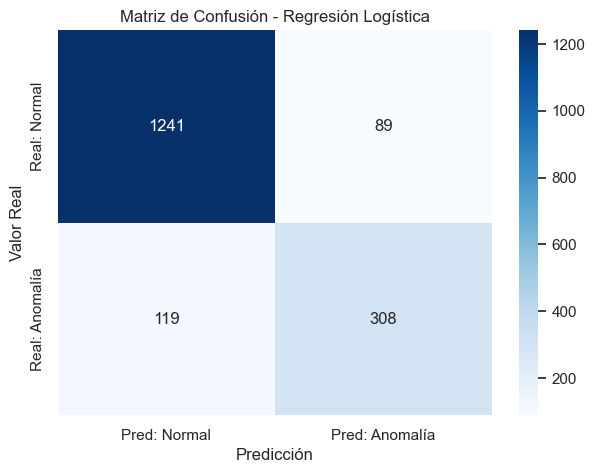

Lectura de la matriz:
  ✅ Verdaderos Negativos:  1241  (70.6%) → Normales bien clasificados
  ⚠️  Falsos Positivos:       89  (5.1%) → Falsas alarmas (inspecciones innecesarias)
  ❌ Falsos Negativos:       119  (6.8%) → Anomalías que se nos escaparon
  ✅ Verdaderos Positivos:   308  (17.5%) → Anomalías detectadas correctamente

De 427 anomalías reales en test, el modelo detectó 308 y se le escaparon 119.


In [34]:
# Matriz de Confusión
cm = confusion_matrix(y_test, pred_log)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Normal', 'Pred: Anomalía'],
            yticklabels=['Real: Normal', 'Real: Anomalía'])
plt.title('Matriz de Confusión - Regresión Logística')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

# Interpretar cada cuadrante con contexto de negocio
vn, fp, fn, vp = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
total = vn + fp + fn + vp

print("Lectura de la matriz:")
print(f"  ✅ Verdaderos Negativos: {vn:>5d}  ({vn/total:.1%}) → Normales bien clasificados")
print(f"  ⚠️  Falsos Positivos:    {fp:>5d}  ({fp/total:.1%}) → Falsas alarmas (inspecciones innecesarias)")
print(f"  ❌ Falsos Negativos:     {fn:>5d}  ({fn/total:.1%}) → Anomalías que se nos escaparon")
print(f"  ✅ Verdaderos Positivos: {vp:>5d}  ({vp/total:.1%}) → Anomalías detectadas correctamente")
print(f"\nDe {fn + vp} anomalías reales en test, el modelo detectó {vp} y se le escaparon {fn}.")

In [35]:
# Reporte completo: Precision, Recall, F1
print(classification_report(y_test, pred_log, target_names=['Normal', 'Anomalía']))

print("El reporte muestra varias métricas por clase. Veamos qué significa cada una.")

              precision    recall  f1-score   support

      Normal       0.91      0.93      0.92      1330
    Anomalía       0.78      0.72      0.75       427

    accuracy                           0.88      1757
   macro avg       0.84      0.83      0.84      1757
weighted avg       0.88      0.88      0.88      1757

El reporte muestra varias métricas por clase. Veamos qué significa cada una.


### ¿Qué significan Precision, Recall y F1?

Estas tres métricas se calculan a partir de la matriz de confusión. Cada una responde una pregunta distinta:

| Métrica | Pregunta que responde | En energía | Fórmula |
|---------|----------------------|-----------|---------|
| **Precision** | De los que marqué como anomalía, ¿cuántos **realmente** lo eran? | "Mandamos 100 órdenes de inspección. ¿En cuántas había fraude de verdad?" | VP / (VP + FP) |
| **Recall** | De todas las anomalías reales, ¿cuántas **logré detectar**? | "Había 50 fraudes reales. ¿Cuántos encontró el modelo?" | VP / (VP + FN) |
| **F1** | ¿Cuál es el balance entre precision y recall? | Compromiso entre falsas alarmas y fraudes no detectados | 2 × (Prec × Rec) / (Prec + Rec) |

**El tradeoff clave:** si bajamos el umbral de decisión del modelo (ej: de 0.5 a 0.3), clasifica más cosas como anomalía → sube el **recall** (detecta más) pero baja la **precision** (más falsas alarmas). Y viceversa.

La **curva Precision-Recall** nos permite ver este tradeoff de forma visual para todos los umbrales posibles.

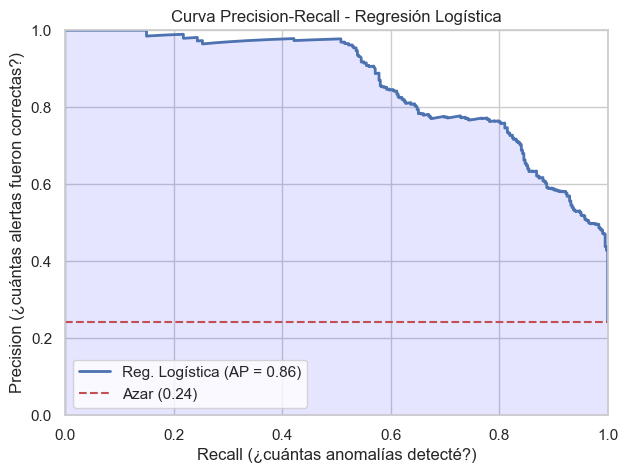

AP (Average Precision) = 0.86

Conclusión: La curva se mantiene bastante arriba de la línea de azar (roja).
El modelo ideal estaría en la esquina superior derecha (precision=1, recall=1).
Veamos si un Árbol de Decisión puede hacerlo mejor.


In [36]:
# Curva Precision-Recall: visualiza el tradeoff entre precision y recall
prob_log = modelo_log.predict_proba(X_test)[:, 1]  # Probabilidad de anomalía
prec_log, rec_log, _ = precision_recall_curve(y_test, prob_log)
ap_log = average_precision_score(y_test, prob_log)

# Línea base: lo que lograría un modelo que clasifica al azar
baseline_pr = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_log, prec_log, 'b-', linewidth=2, label=f'Reg. Logística (AP = {ap_log:.2f})')
plt.axhline(y=baseline_pr, color='r', linestyle='--', label=f'Azar ({baseline_pr:.2f})')
plt.fill_between(rec_log, prec_log, alpha=0.1, color='blue')
plt.xlabel('Recall (¿cuántas anomalías detecté?)')
plt.ylabel('Precision (¿cuántas alertas fueron correctas?)')
plt.title('Curva Precision-Recall - Regresión Logística')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

print(f"AP (Average Precision) = {ap_log:.2f}")
print(f"\nConclusión: La curva se mantiene bastante arriba de la línea de azar (roja).")
print(f"El modelo ideal estaría en la esquina superior derecha (precision=1, recall=1).")
print(f"Veamos si un Árbol de Decisión puede hacerlo mejor.")

In [37]:
# 1.5 Segundo modelo: Árbol de Decisión
# Mismo concepto que en Módulo 1, pero para clasificación:
# en vez de predecir MW, predice Normal o Anomalía.
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)
pred_arbol = modelo_arbol.predict(X_test)

print("=== Árbol de Decisión ===")
print(classification_report(y_test, pred_arbol, target_names=['Normal', 'Anomalía']))

print("Conclusión: El árbol supera a la regresión logística en la detección de anomalías.")
print("Puede aprender reglas como '¿es madrugada Y temperatura extrema?' que un modelo lineal no captura.")

=== Árbol de Decisión ===
              precision    recall  f1-score   support

      Normal       0.97      0.91      0.94      1330
    Anomalía       0.77      0.90      0.83       427

    accuracy                           0.91      1757
   macro avg       0.87      0.91      0.89      1757
weighted avg       0.92      0.91      0.91      1757

Conclusión: El árbol supera a la regresión logística en la detección de anomalías.
Puede aprender reglas como '¿es madrugada Y temperatura extrema?' que un modelo lineal no captura.


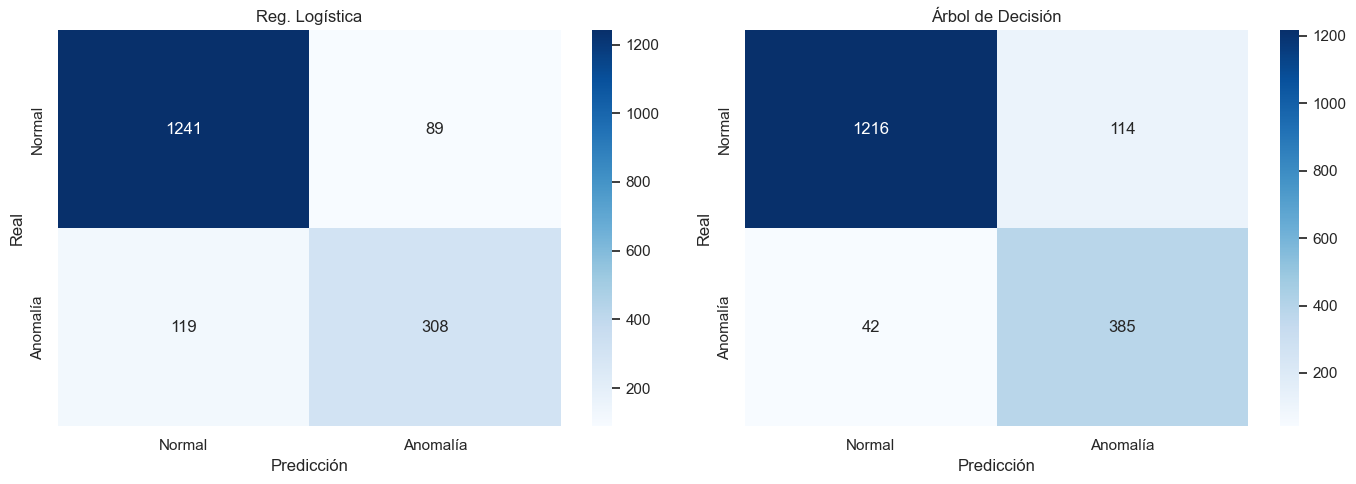

Conclusión: El árbol detecta más anomalías (VP: 385 vs 308)
y deja escapar menos (FN: 42 vs 119).
Comparemos también las curvas Precision-Recall de ambos modelos.


In [38]:
# Comparar matrices de confusión lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, titulo in zip(axes, [pred_log, pred_arbol], ['Reg. Logística', 'Árbol de Decisión']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomalía'], yticklabels=['Normal', 'Anomalía'])
    ax.set_title(titulo)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.show()

cm_log = confusion_matrix(y_test, pred_log)
cm_arb = confusion_matrix(y_test, pred_arbol)
print(f"Conclusión: El árbol detecta más anomalías (VP: {cm_arb[1][1]} vs {cm_log[1][1]})")
print(f"y deja escapar menos (FN: {cm_arb[1][0]} vs {cm_log[1][0]}).")
print(f"Comparemos también las curvas Precision-Recall de ambos modelos.")

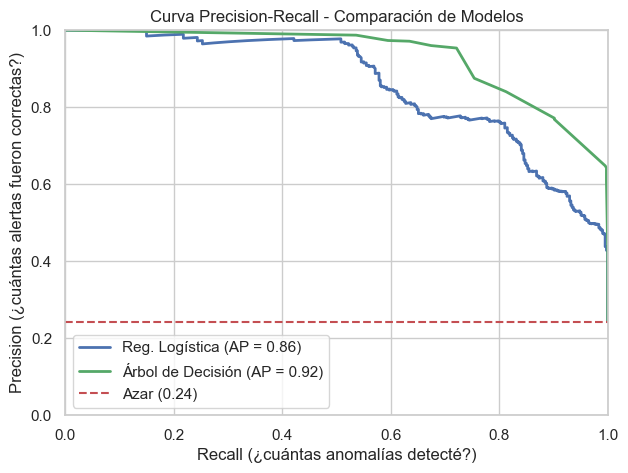

Conclusión: El árbol (verde, AP=0.92) domina a la logística (azul, AP=0.86).
Para cualquier nivel de recall, el árbol mantiene mejor precision.


In [39]:
# Comparar curvas Precision-Recall de ambos modelos
prob_log = modelo_log.predict_proba(X_test)[:, 1]
prob_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

prec_log, rec_log, _ = precision_recall_curve(y_test, prob_log)
prec_arb, rec_arb, _ = precision_recall_curve(y_test, prob_arbol)
ap_log = average_precision_score(y_test, prob_log)
ap_arb = average_precision_score(y_test, prob_arbol)

baseline_pr = y_test.mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_log, prec_log, 'b-', linewidth=2, label=f'Reg. Logística (AP = {ap_log:.2f})')
plt.plot(rec_arb, prec_arb, 'g-', linewidth=2, label=f'Árbol de Decisión (AP = {ap_arb:.2f})')
plt.axhline(y=baseline_pr, color='r', linestyle='--', label=f'Azar ({baseline_pr:.2f})')
plt.xlabel('Recall (¿cuántas anomalías detecté?)')
plt.ylabel('Precision (¿cuántas alertas fueron correctas?)')
plt.title('Curva Precision-Recall - Comparación de Modelos')
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

print(f"Conclusión: El árbol (verde, AP={ap_arb:.2f}) domina a la logística (azul, AP={ap_log:.2f}).")
print(f"Para cualquier nivel de recall, el árbol mantiene mejor precision.")

### 1.6 El problema de las clases desbalanceadas

Volvamos a mirar la distribución de nuestros datos:

```
  Normal:   ~80%  ████████████████████████████████████████░░░░░░░░░░
  Anomalía: ~20%  ████████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
```

En nuestro caso las anomalías son ~20%, lo cual no es tan extremo. Pero en problemas reales de energía, los ratios pueden ser mucho peores:
- **Fraude:** ~2-5% de los clientes
- **Fallas en transformadores:** ~1% por año
- **Accidentes de línea:** < 0.1%

Cuando una clase es muy minoritaria, el modelo aprende a "ignorarla" porque equivocarse en esos pocos casos apenas afecta el accuracy total. La solución rápida: **`class_weight='balanced'`**, que le dice al modelo que penalice más los errores en la clase minoritaria.

In [40]:
# class_weight='balanced' le da más importancia a la clase minoritaria
modelo_balanceado = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
modelo_balanceado.fit(X_train, y_train)
pred_bal = modelo_balanceado.predict(X_test)

print("=== Árbol con class_weight='balanced' ===")
print(classification_report(y_test, pred_bal, target_names=['Normal', 'Anomalía']))

print("Conclusión: Con 'balanced', el recall de Anomalía sube mucho (detecta más fraudes),")
print("pero la precision baja (más falsas alarmas). Es el tradeoff en acción:")
print("¿preferimos detectar todo aunque haya más inspecciones innecesarias?")

=== Árbol con class_weight='balanced' ===
              precision    recall  f1-score   support

      Normal       1.00      0.83      0.91      1330
    Anomalía       0.65      1.00      0.79       427

    accuracy                           0.87      1757
   macro avg       0.82      0.91      0.85      1757
weighted avg       0.91      0.87      0.88      1757

Conclusión: Con 'balanced', el recall de Anomalía sube mucho (detecta más fraudes),
pero la precision baja (más falsas alarmas). Es el tradeoff en acción:
¿preferimos detectar todo aunque haya más inspecciones innecesarias?


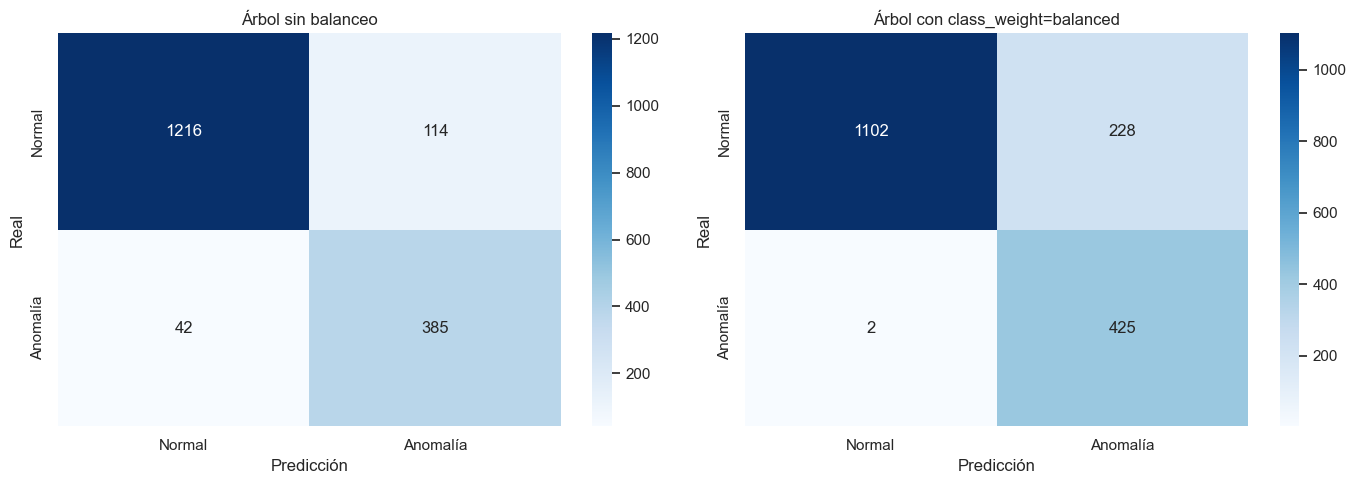

Observar cómo cambia el balance entre Falsos Positivos y Falsos Negativos.
Con 'balanced': detecta más anomalías (menos FN) pero genera más falsas alarmas (más FP).
¿Cuál es mejor? Depende del costo de cada tipo de error en el negocio.


In [41]:
# Comparar: sin balanceo vs con balanceo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, titulo in zip(axes, [pred_arbol, pred_bal],
                              ['Árbol sin balanceo', 'Árbol con class_weight=balanced']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Anomalía'], yticklabels=['Normal', 'Anomalía'])
    ax.set_title(titulo)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.show()

print("Observar cómo cambia el balance entre Falsos Positivos y Falsos Negativos.")
print("Con 'balanced': detecta más anomalías (menos FN) pero genera más falsas alarmas (más FP).")
print("¿Cuál es mejor? Depende del costo de cada tipo de error en el negocio.")

### Resumen Bloque 1: Clasificación

- **Accuracy sola engaña.** Siempre mirar la matriz de confusión, precision, recall y F1.
- **Precision vs Recall** es un tradeoff: detectar más anomalías implica más falsas alarmas.
- **Curva Precision-Recall** permite visualizar ese tradeoff para distintos umbrales.
- **El árbol de decisión** supera a la regresión logística cuando los patrones no son lineales.
- **class_weight='balanced'** ayuda cuando una clase es muy minoritaria.

---

## Bloque 2: Aprendizaje No Supervisado

### 2.1 ¿Qué cambia?

Hasta ahora **siempre teníamos la respuesta** (target/y): la demanda real, o la etiqueta anomalía/normal. Alguien (o alguna regla) nos decía cuál era la respuesta correcta, y el modelo aprendía a replicarla.

En **no supervisado**, NO hay target. No le decimos al algoritmo qué buscar. El algoritmo explora los datos y busca **estructura oculta** por su cuenta.

**Analogía:** Es como darle una pila de fotos a alguien sin decirle las categorías. Esa persona podría agruparlas por color, por tema, por ubicación... El algoritmo hace algo similar: encuentra "grupos naturales" en los datos.

| Supervisado | No Supervisado |
|-------------|---------------|
| Tenemos etiquetas (y) | NO hay etiquetas |
| Regresión, Clasificación | Clustering, Reducción de dimensionalidad |
| "Predecir demanda" | "Agrupar clientes similares" |
| "Detectar fraude (sí/no)" | "Encontrar patrones ocultos en sensores" |

### 2.2 K-Means Clustering

**Idea:** Encontrar K grupos "naturales" en los datos, donde los puntos dentro de cada grupo son similares entre sí.

**Caso de uso:** Segmentar clientes/transformadores por patrón de consumo. Útil para:
- Diseñar tarifas diferenciadas
- Priorizar mantenimiento
- Detectar comportamientos inusuales

**¿Cómo funciona? (simplificado)**
1. Elegir K centroides al azar
2. Asignar cada punto al centroide más cercano
3. Mover cada centroide al centro de su grupo
4. Repetir hasta que no cambie

In [42]:
# Crear datos de clientes con diferentes perfiles de consumo
np.random.seed(42)

clientes = pd.DataFrame({
    'consumo_promedio_kwh': np.concatenate([
        np.random.normal(150, 30, 80),     # Residencial bajo
        np.random.normal(400, 50, 70),     # Residencial alto
        np.random.normal(1200, 200, 50)    # Comercial/Industrial
    ]),
    'variabilidad_consumo': np.concatenate([
        np.random.normal(20, 5, 80),
        np.random.normal(60, 15, 70),
        np.random.normal(150, 30, 50)
    ]),
    'pico_horario': np.concatenate([
        np.random.normal(20, 2, 80),       # Pico nocturno
        np.random.normal(14, 3, 70),       # Pico tarde
        np.random.normal(10, 2, 50)        # Pico mañana
    ])
})

print(f"Tenemos {len(clientes)} clientes con 3 características cada uno.")
clientes.head()

Tenemos 200 clientes con 3 características cada uno.


,consumo_promedio_kwh,variabilidad_consumo,pico_horario
0,164.901425,21.788937,16.811145
1,145.852071,22.803923,18.801250
2,169.430656,25.415256,20.010487
3,195.690896,25.269010,20.093961
4,142.975399,13.111653,19.099869


### ¿Por qué normalizar antes de clustering?

K-Means agrupa puntos por **distancia**. Si una columna tiene valores de 0 a 1500 (consumo en kWh) y otra de 0 a 24 (hora pico), la primera domina completamente el cálculo de distancia. La hora pico casi no influiría.

**Normalizar** (con `StandardScaler`) transforma cada columna para que tenga media 0 y desviación 1. Así todas las features pesan igual en la distancia.

```
Antes:    consumo = 1200 kWh,  variabilidad = 150,  pico = 10
Después:  consumo = 1.2,       variabilidad = 1.1,  pico = -0.3
```

In [43]:
# Importante: normalizar los datos antes de clustering
scaler = StandardScaler()
clientes_norm = scaler.fit_transform(clientes)

# Aplicar K-Means con K=3 (sospechamos 3 tipos de clientes)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clientes['cluster'] = kmeans.fit_predict(clientes_norm)

print("Clientes por cluster:")
print(clientes['cluster'].value_counts().sort_index())
print(f"\nK-Means encontró 3 grupos de tamaños distintos.")
print("Veamos en un gráfico cómo se distribuyen y qué los diferencia.")

Clientes por cluster:
cluster
0    50
1    86
2    64
Name: count, dtype: int64

K-Means encontró 3 grupos de tamaños distintos.
Veamos en un gráfico cómo se distribuyen y qué los diferencia.


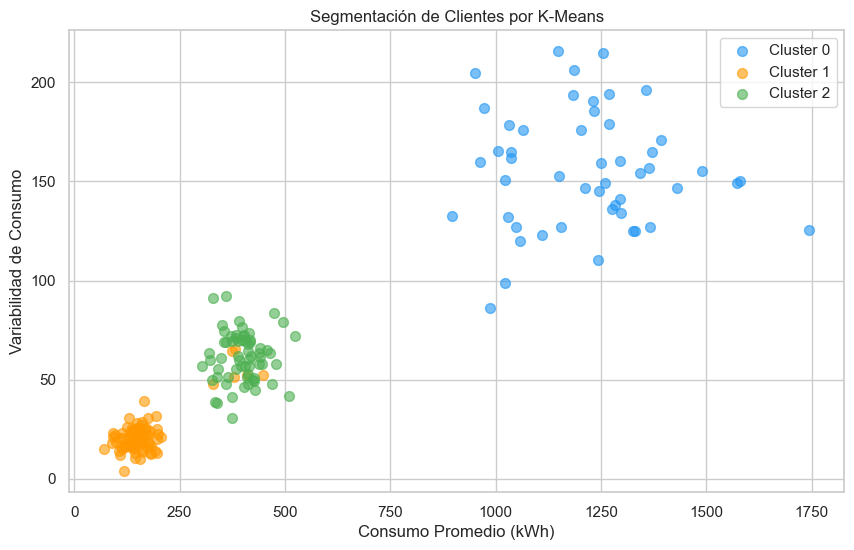

Conclusión: K-Means separó claramente 3 perfiles de clientes.
Los clusters se distinguen por consumo y variabilidad: clientes chicos (azul),
medianos (naranja) y grandes (verde). Esto podría usarse para diseñar tarifas
diferenciadas o priorizar inspecciones en el grupo que más consuma.


In [44]:
# Visualizar los clusters
plt.figure(figsize=(10, 6))
colores = ['#2196F3', '#FF9800', '#4CAF50']
for c in sorted(clientes['cluster'].unique()):
    mask = clientes['cluster'] == c
    plt.scatter(clientes.loc[mask, 'consumo_promedio_kwh'],
                clientes.loc[mask, 'variabilidad_consumo'],
                c=colores[c], label=f'Cluster {c}', alpha=0.6, s=50)

plt.xlabel('Consumo Promedio (kWh)')
plt.ylabel('Variabilidad de Consumo')
plt.title('Segmentación de Clientes por K-Means')
plt.legend()
plt.show()

print("Conclusión: K-Means separó claramente 3 perfiles de clientes.")
print("Los clusters se distinguen por consumo y variabilidad: clientes chicos (azul),")
print("medianos (naranja) y grandes (verde). Esto podría usarse para diseñar tarifas")
print("diferenciadas o priorizar inspecciones en el grupo que más consuma.")

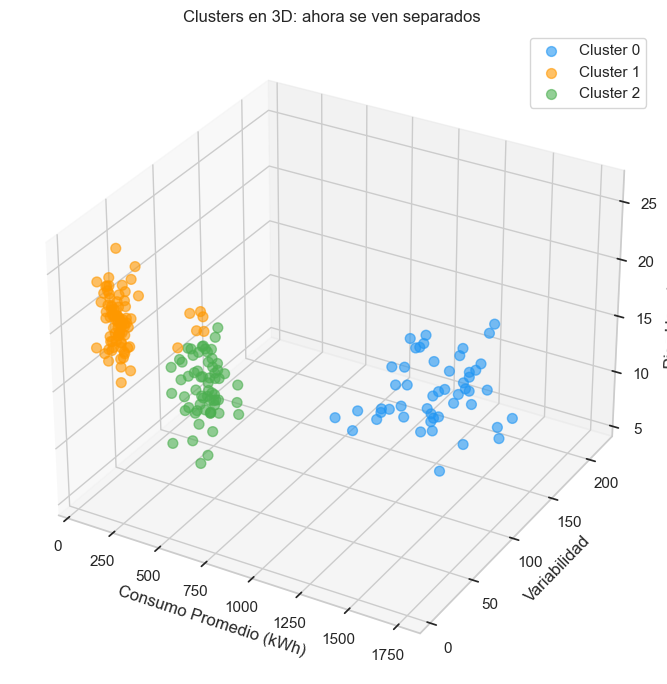

Conclusión: En 3D se ve que los clusters que parecían superpuestos en 2D
están separados por la tercera variable (pico horario).
El naranja tiene pico a la tarde (~14hs), el verde a la mañana (~10hs).
Cuando tenemos muchas dimensiones, es difícil visualizar los datos.
Por eso más adelante veremos PCA, que reduce dimensiones para poder graficar.


In [45]:
# En 2D algunos clusters se superponen. Veamos las 3 dimensiones juntas.
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colores = ['#2196F3', '#FF9800', '#4CAF50']
for c in sorted(clientes['cluster'].unique()):
    mask = clientes['cluster'] == c
    ax.scatter(clientes.loc[mask, 'consumo_promedio_kwh'],
               clientes.loc[mask, 'variabilidad_consumo'],
               clientes.loc[mask, 'pico_horario'],
               c=colores[c], label=f'Cluster {c}', alpha=0.6, s=50)

ax.set_xlabel('Consumo Promedio (kWh)')
ax.set_ylabel('Variabilidad')
ax.set_zlabel('Pico Horario (hora)')
ax.set_title('Clusters en 3D: ahora se ven separados')
ax.legend()
plt.tight_layout()
plt.show()

print("Conclusión: En 3D se ve que los clusters que parecían superpuestos en 2D")
print("están separados por la tercera variable (pico horario).")
print("El naranja tiene pico a la tarde (~14hs), el verde a la mañana (~10hs).")
print("Cuando tenemos muchas dimensiones, es difícil visualizar los datos.")
print("Por eso más adelante veremos PCA, que reduce dimensiones para poder graficar.")

In [46]:
# Interpretar los clusters: ¿qué caracteriza a cada grupo?
resumen = clientes.groupby('cluster').mean().round(1)
resumen.index = ['Cluster 0', 'Cluster 1', 'Cluster 2']
print("Perfil promedio de cada cluster:")
print(resumen)
print("\nInterpretación posible:")
print("- Consumo bajo + poca variabilidad + pico nocturno = Residencial básico")
print("- Consumo medio + variabilidad media + pico tarde = Residencial con AC")
print("- Consumo alto + mucha variabilidad + pico mañana = Comercial/Industrial")

Perfil promedio de cada cluster:
           consumo_promedio_kwh  variabilidad_consumo  pico_horario
Cluster 0                1216.8                 155.4          10.1
Cluster 1                 163.1                  22.7          19.9
Cluster 2                 399.3                  61.6          12.8

Interpretación posible:
- Consumo bajo + poca variabilidad + pico nocturno = Residencial básico
- Consumo medio + variabilidad media + pico tarde = Residencial con AC
- Consumo alto + mucha variabilidad + pico mañana = Comercial/Industrial


### 2.3 Método del Codo: ¿cuántos clusters elegir?

No siempre sabemos cuántos grupos hay. El **método del codo** prueba varios K y busca el punto donde agregar más clusters deja de mejorar significativamente.

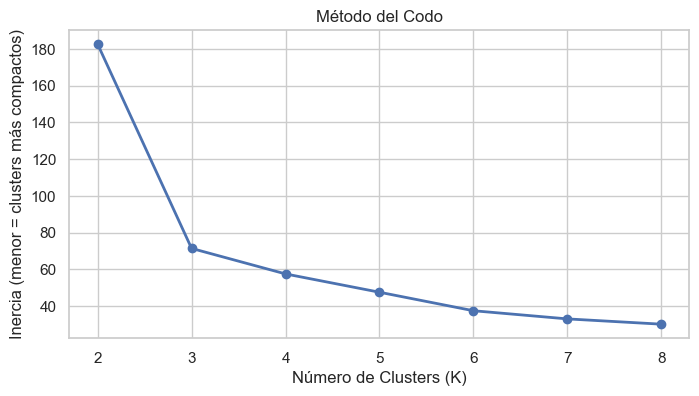

Buscar el 'codo': donde la curva deja de bajar mucho. En este caso, K=3.


In [47]:
# Probar K de 2 a 8
inercias = []
rango_k = range(2, 9)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clientes_norm)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, 'bo-', linewidth=2)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (menor = clusters más compactos)')
plt.title('Método del Codo')
plt.xticks(rango_k)
plt.show()
print("Buscar el 'codo': donde la curva deja de bajar mucho. En este caso, K=3.")

### 2.4 PCA: Reducción de Dimensionalidad

**Problema:** A veces tenemos muchas columnas (ej: consumo de cada hora = 24 columnas). Es difícil visualizar o trabajar con tantas dimensiones.

**PCA (Análisis de Componentes Principales)** reduce muchas columnas a pocas, manteniendo la mayor cantidad de información posible.

**Caso de uso:** Tenemos el perfil de consumo horario de 200 clientes (24 columnas). Queremos visualizarlos en 2D.

In [48]:
# Crear perfiles de consumo horario (24 features por cliente)
np.random.seed(42)
n_clientes = 200
horas_pca = np.arange(24)
perfiles = np.zeros((n_clientes, 24))

# 100 clientes residenciales: pico en la noche (~20hs)
for i in range(100):
    base = np.random.normal(100, 20)
    perfiles[i] = base + 50*np.exp(-0.5*((horas_pca-20)/3)**2) + np.random.normal(0, 10, 24)

# 100 clientes comerciales: pico al mediodía (~12hs)
for i in range(100, 200):
    base = np.random.normal(300, 50)
    perfiles[i] = base + 150*np.exp(-0.5*((horas_pca-12)/4)**2) + np.random.normal(0, 20, 24)

# Etiqueta real (para colorear, pero el modelo NO la ve)
tipo_real = ['Residencial']*100 + ['Comercial']*100

print(f"Datos: {perfiles.shape[0]} clientes x {perfiles.shape[1]} horas")
print("Cada fila es el perfil de consumo horario de un cliente.")

Datos: 200 clientes x 24 horas
Cada fila es el perfil de consumo horario de un cliente.


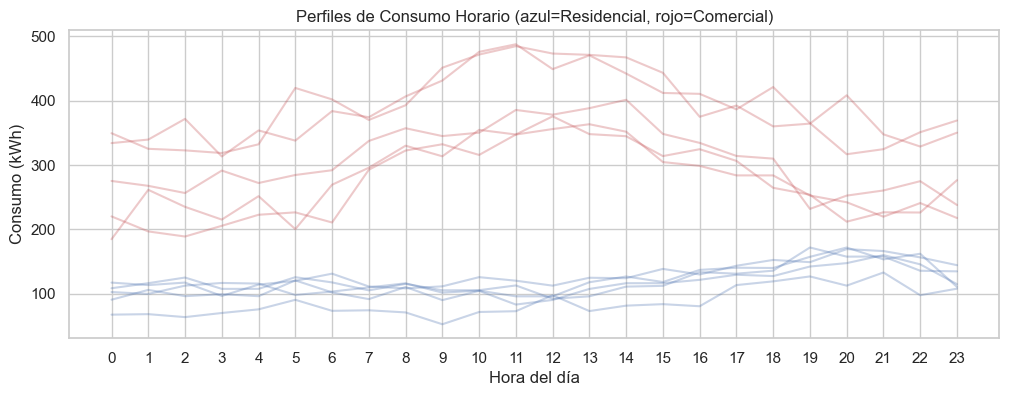

Conclusión: Los dos tipos de clientes tienen patrones claramente distintos.
Residenciales (azul): consumo bajo, pico a la noche (~20hs, cuando llegan a casa).
Comerciales (rojo): consumo alto, pico al mediodía (~12hs, horario laboral).
El desafío: ¿podemos descubrir estos grupos con 24 columnas sin verlos en un gráfico?


In [49]:
# Visualizar algunos perfiles de ejemplo
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.plot(horas_pca, perfiles[i], 'b-', alpha=0.3)    # Residenciales en azul
    plt.plot(horas_pca, perfiles[100+i], 'r-', alpha=0.3) # Comerciales en rojo

plt.xlabel('Hora del día')
plt.ylabel('Consumo (kWh)')
plt.title('Perfiles de Consumo Horario (azul=Residencial, rojo=Comercial)')
plt.xticks(range(24))
plt.show()

print("Conclusión: Los dos tipos de clientes tienen patrones claramente distintos.")
print("Residenciales (azul): consumo bajo, pico a la noche (~20hs, cuando llegan a casa).")
print("Comerciales (rojo): consumo alto, pico al mediodía (~12hs, horario laboral).")
print("El desafío: ¿podemos descubrir estos grupos con 24 columnas sin verlos en un gráfico?")

In [50]:
# Aplicar PCA: reducir de 24 dimensiones a 2
scaler_pca = StandardScaler()
perfiles_norm = scaler_pca.fit_transform(perfiles)

pca = PCA(n_components=2)
perfiles_2d = pca.fit_transform(perfiles_norm)

print(f"Dimensiones originales: {perfiles.shape[1]} (una por hora)")
print(f"Dimensiones reducidas: {perfiles_2d.shape[1]}")
print(f"\nInformación retenida:")
print(f"  Componente 1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  Componente 2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total:        {sum(pca.explained_variance_ratio_):.1%}")
print(f"\nConclusión: Con solo 2 componentes capturamos {sum(pca.explained_variance_ratio_):.0%}")
print("de la información que estaba en las 24 columnas originales. Eso significa que")
print("la mayor parte de la variación entre clientes se puede resumir en 2 números.")

Dimensiones originales: 24 (una por hora)
Dimensiones reducidas: 2

Información retenida:
  Componente 1: 97.7%
  Componente 2: 0.6%
  Total:        98.3%

Conclusión: Con solo 2 componentes capturamos 98%
de la información que estaba en las 24 columnas originales. Eso significa que
la mayor parte de la variación entre clientes se puede resumir en 2 números.


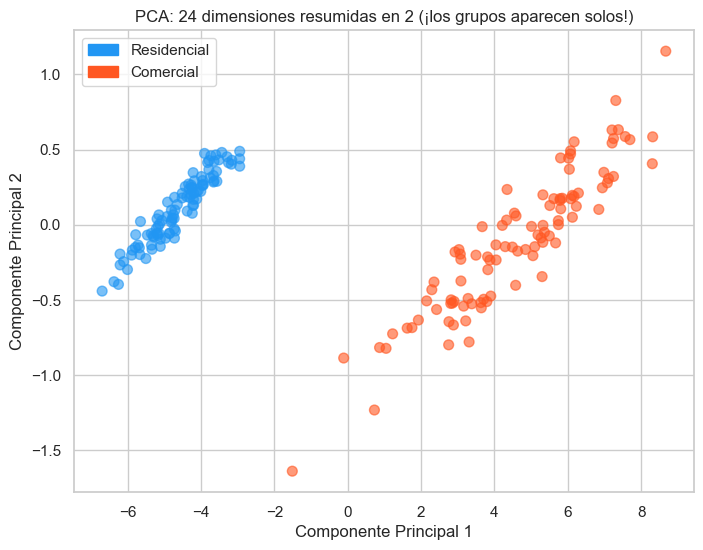

PCA redujo 24 columnas a 2, y los tipos de clientes se separan claramente.
Esto es útil para visualizar datos de alta dimensión.


In [51]:
# Visualizar en 2D: ¡los grupos aparecen naturalmente!
from matplotlib.patches import Patch

plt.figure(figsize=(8, 6))
colores_tipo = ['#2196F3' if t == 'Residencial' else '#FF5722' for t in tipo_real]
plt.scatter(perfiles_2d[:, 0], perfiles_2d[:, 1], c=colores_tipo, alpha=0.6, s=50)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA: 24 dimensiones resumidas en 2 (¡los grupos aparecen solos!)')

plt.legend(handles=[Patch(color='#2196F3', label='Residencial'),
                     Patch(color='#FF5722', label='Comercial')])
plt.show()
print("PCA redujo 24 columnas a 2, y los tipos de clientes se separan claramente.")
print("Esto es útil para visualizar datos de alta dimensión.")

### Resumen Bloque 2: No Supervisado

| Técnica | ¿Qué hace? | Caso en energía |
|---------|----------|------------------|
| **K-Means** | Agrupa datos similares | Segmentar clientes, agrupar transformadores |
| **PCA** | Reduce dimensiones | Resumir perfiles horarios, comprimir datos de sensores |

- K-Means necesita que elijamos K (método del codo ayuda).
- PCA resume muchas columnas en pocas, perdiendo mínima información.
- Ambos son **no supervisados**: no necesitan etiquetas.

---

## Bloque 3: Ciclo de Vida de un Proyecto de ML

### 3.1 CRISP-DM: la receta para proyectos de datos

Hasta ahora nos enfocamos en la parte técnica: entrenar modelos, evaluar métricas. Pero en la realidad, eso es solo **una parte** de un proyecto de ML. Si no se define bien el problema de negocio, o si no hay un plan de monitoreo, el modelo termina en un notebook que nadie usa.

**CRISP-DM** es una metodología estándar que define las etapas de un proyecto de datos:

```
  1. Entendimiento          2. Entendimiento          3. Preparación
     del NEGOCIO     -->       de los DATOS     -->       de DATOS
          |                                                   |
          |                                                   v
  6. DESPLIEGUE      <--    5. EVALUACIÓN       <--    4. MODELADO
          |
          v
  7. MONITOREO (nuevo - MLOps)
```

**Atención:** El 80% del tiempo de un proyecto de ML se va en los pasos 2 y 3 (entender y preparar datos), no en el paso 4 (modelar). Esto sorprende a muchos equipos que piensan que "hacer IA" es solo entrenar modelos.

### Cada paso aplicado a energía:

| Paso | Descripción | Ejemplo |
|------|-------------|------|
| 1. Negocio | Definir qué problema resolver y cómo medir éxito | "Reducir pérdidas no técnicas (fraude) en 10%" |
| 2. Datos | Explorar qué datos existen y su calidad | AMI, SCADA, clima, reclamos, topología de red |
| 3. Preparación | Limpiar, transformar, crear features | Rellenar faltantes, crear ratios, unir tablas |
| 4. Modelado | Elegir y entrenar modelos | Probar Logística, Árbol, XGBoost |
| 5. Evaluación | ¿El modelo resuelve el problema de NEGOCIO? | F1 > 0.7? ¿Reduce inspecciones fallidas? |
| 6. Despliegue | Poner en producción | API que recibe medición y devuelve score |
| 7. Monitoreo | Vigilar que siga funcionando | Alertas si las métricas bajan (¡data drift!) |

### 3.2 Data Drift: cuando el modelo se pudre

Un modelo entrenado con datos de **invierno** puede fallar en **verano** porque los patrones cambian. Esto se llama **data drift** (desvío de datos).

Veamos un ejemplo:

In [52]:
# Simulación: entrenar SOLO con datos de invierno y evaluar en verano
invierno = df[(df['fecha'].dt.month >= 6) & (df['fecha'].dt.month <= 8)]  # Jun-Ago
verano = df[(df['fecha'].dt.month == 1) | (df['fecha'].dt.month == 12)]   # Dic-Ene

features_drift = ['temperatura', 'hora', 'es_finde']

# Modelo entrenado solo en invierno
modelo_inv = DecisionTreeRegressor(max_depth=5, random_state=42)
modelo_inv.fit(invierno[features_drift], invierno['demanda_MW'])

# Evaluar en invierno (datos conocidos) vs verano (datos nuevos)
mae_inv = mean_absolute_error(invierno['demanda_MW'], modelo_inv.predict(invierno[features_drift]))
mae_ver = mean_absolute_error(verano['demanda_MW'], modelo_inv.predict(verano[features_drift]))

print(f"MAE en invierno (datos de entrenamiento): {mae_inv:.2f} MW")
print(f"MAE en verano (datos nuevos):             {mae_ver:.2f} MW")
print(f"\n¡El error en verano es {mae_ver/mae_inv:.1f}x mayor!")
print("Esto es DATA DRIFT: el modelo se 'pudrió' porque los datos cambiaron.")

MAE en invierno (datos de entrenamiento): 6.07 MW
MAE en verano (datos nuevos):             114.71 MW

¡El error en verano es 18.9x mayor!
Esto es DATA DRIFT: el modelo se 'pudrió' porque los datos cambiaron.


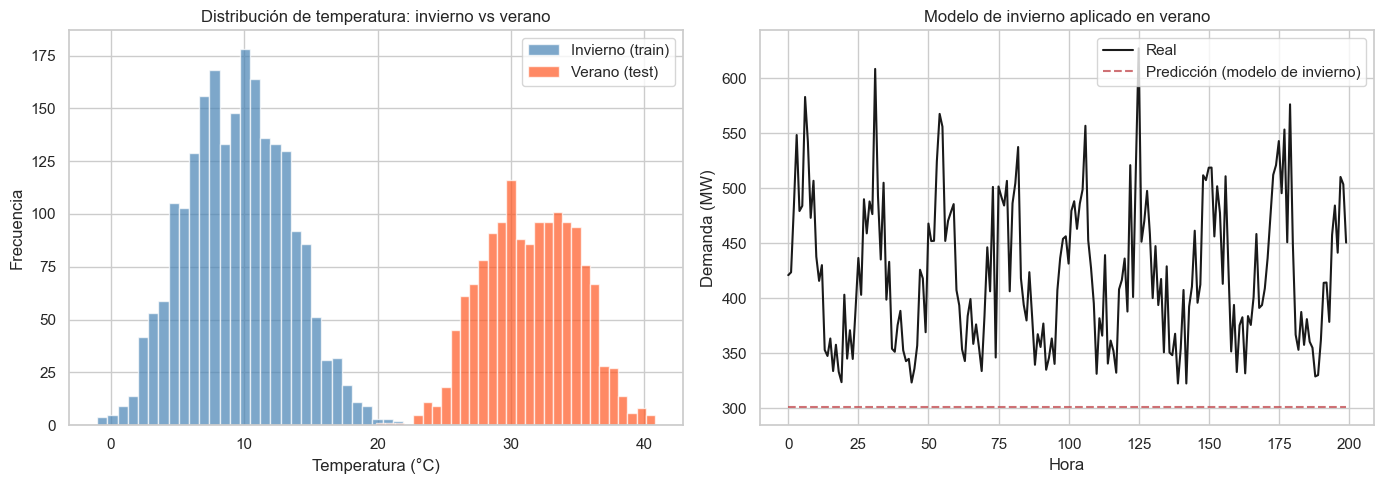

Izquierda: las temperaturas de verano son muy distintas a las de invierno.
Derecha: el modelo no puede predecir bien en condiciones que nunca vio.

Lección: un modelo necesita monitoreo continuo y re-entrenamiento periódico.


In [53]:
# Visualizar: ¿por qué el modelo falla en verano?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución de temperaturas
axes[0].hist(invierno['temperatura'], bins=30, alpha=0.7, color='steelblue', label='Invierno (train)')
axes[0].hist(verano['temperatura'], bins=30, alpha=0.7, color='#FF5722', label='Verano (test)')
axes[0].set_xlabel('Temperatura (°C)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de temperatura: invierno vs verano')
axes[0].legend()

# Predicciones vs realidad en verano
muestra_ver = verano.head(200)
pred_ver = modelo_inv.predict(muestra_ver[features_drift])
axes[1].plot(range(len(muestra_ver)), muestra_ver['demanda_MW'].values, 'k-', label='Real', linewidth=1.5)
axes[1].plot(range(len(muestra_ver)), pred_ver, 'r--', label='Predicción (modelo de invierno)', alpha=0.8)
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Demanda (MW)')
axes[1].set_title('Modelo de invierno aplicado en verano')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Izquierda: las temperaturas de verano son muy distintas a las de invierno.")
print("Derecha: el modelo no puede predecir bien en condiciones que nunca vio.")
print("\nLección: un modelo necesita monitoreo continuo y re-entrenamiento periódico.")

### 3.3 Checklist para iniciar un piloto de ML

Antes de arrancar un proyecto, verificar:

- [ ] **Problema definido:** ¿Qué queremos predecir/detectar/optimizar?
- [ ] **Métrica de éxito clara:** ¿Cómo sabemos si el modelo sirve? (MAE < X, F1 > Y)
- [ ] **Datos disponibles:** ¿Tenemos datos históricos suficientes? ¿Están accesibles?
- [ ] **Calidad de datos:** ¿Hay faltantes? ¿Errores? ¿Se actualizan?
- [ ] **Etiquetas:** Para supervisado, ¿tenemos la variable target? ¿Quién la valida?
- [ ] **Equipo:** ¿Quién construye el modelo? ¿Quién lo mantiene en producción?
- [ ] **Infraestructura:** ¿Dónde se ejecuta? ¿Con qué frecuencia?
- [ ] **Plan de monitoreo:** ¿Cómo detectamos si el modelo deja de funcionar?
- [ ] **Criterio de salida:** ¿Cuándo decidimos que el proyecto no funcionó?

---
## Conclusión del Módulo 2

### Mapa completo de ML (hasta ahora)

```
Machine Learning
├── Supervisado (con etiquetas)
│   ├── Regresión: predecir un número (Módulo 1)
│   │   └── Reg. Lineal, Árbol de Decisión
│   └── Clasificación: predecir una categoría (Módulo 2)
│       └── Reg. Logística, Árbol de Decisión
│           └── Métricas: Precision, Recall, F1
└── No Supervisado (sin etiquetas)
    ├── Clustering: encontrar grupos (Módulo 2)
    │   └── K-Means, Método del Codo
    └── Reducción: comprimir dimensiones (Módulo 2)
        └── PCA
```

### Próximo módulo:

**Módulo 3: Modelos Avanzados** - Random Forest, XGBoost, Deep Learning (LSTM) para series temporales, y una introducción conceptual a Aprendizaje por Refuerzo.